# Water Quality in a Drinking Water Distribution Network

## Learning Objectives

- Represent a branching distribution network as a discrete pore volume distribution
- Derive the *effective* pore volume of a path: each pipe's volume divided by the fraction of plant flow it carries
- Understand why a shared trunk main is counted in full for every downstream path, never divided among them
- Track a contamination pulse and disinfectant residual from the treatment plant to individual taps

## Overview

The transport model in this package moves water along a bundle of parallel streamtubes, each
characterised by a pore volume. Nothing in that formulation is specific to an aquifer: it only
requires that every water parcel follows a fixed path whose local velocity is proportional to a
measured source flow. A branching drinking water network satisfies exactly that, so the same
machinery predicts travel time and water quality from the treatment plant to each tap.

### Key Assumptions

- **Tree topology, single source.** The path from plant to tap is unique. Flows may split but never
  merge, because a split leaves concentration unchanged while a merge blends two different
  histories that a single-source model cannot represent.
- **Proportional demand.** Every segment carries a constant fraction of plant production, so
  demand patterns scale together over the day ([steady streamlines](https://gwtransport.github.io/gwtransport/user_guide/assumptions.html#assumption-steady-streamlines)).
- **Plug flow per pipe.** Turbulent mains are close to plug flow; longitudinal dispersion is neglected.
- **Complete mixing at junctions**, so each branch inherits the upstream concentration.

### Background Reading

- [Pore Volume Distribution](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-pore-volume-distribution) — how a distribution of travel paths is represented
- [Residence Time](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-residence-time) — travel time between input and output
- [Transport Equation](https://gwtransport.github.io/gwtransport/user_guide/concepts.html#concept-transport-equation) — flow-weighted averaging convention

## Theoretical Background

### Effective pore volume of a path

A parcel travelling through pipe segment $i$ with water volume $V_i$ needs a throughflow of $V_i$
through *that segment* to traverse it. The segment carries only a fraction $f_i$ of the plant
production $Q(t)$, so in terms of plant throughflow the parcel consumes $V_i / f_i$. Summing over
the segments of a path gives the condition for a parcel infiltrated at $t_{in}$ to arrive at $t_{out}$:

$$\int_{t_{in}}^{t_{out}} Q(t)\,\mathrm{d}t = \sum_{i \in \mathrm{path}} \frac{V_i}{f_i} \equiv V_{\mathrm{eff}}$$

The right-hand side is a constant of the path, expressed in units of plant throughflow — precisely
the role an `aquifer_pore_volume` plays in this package. A 50 L service line carrying 0.1 % of the
plant flow contributes as much effective volume as a 50 m³ trunk main carrying all of it.

### The shared trunk is not divided

A segment's own flow fraction $f_i$ appears in the denominator, not the fraction of the destination
tap. The trunk main has $f = 1$ and therefore contributes its **full** volume to every downstream
path.

This is exact, not an approximation. Slice the trunk lengthwise into virtual sub-tubes, one per
downstream tap, sized in proportion to the flow fraction $f_j$ that tap will eventually draw.
Sub-tube $j$ holds volume $f_j V_0$ and carries flow $f_j Q(t)$, so its transit requires
$\int f_j Q\,\mathrm{d}t = f_j V_0$, that is $\int Q\,\mathrm{d}t = V_0$ — the same plant throughflow
for every tap. The plug therefore moves down the trunk as one body and reaches the junction
simultaneously in all sub-tubes, which is the physical behaviour of a shared main.

A consequence worth remembering: spread in the pore volume distribution comes only from *asymmetry*
between paths. A network that is one long main with a symmetric fan-out at the end behaves almost
like a single plug.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.dates import date2num
from matplotlib.lines import Line2D

import gwtransport.residence_time as rt
from gwtransport.advection import infiltration_to_extraction
from gwtransport.utils import step_plot_coords

plt.style.use("seaborn-v0_8-whitegrid")

# Validated categorical palette (one hue per tap), sequential blue ramp for flow fraction
TAP_COLORS = {"T1": "#2a78d6", "T2": "#eb6834", "T3": "#1baf7a", "T4": "#eda100"}
BLUES = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"]
BLUE_RAMP = LinearSegmentedColormap.from_list("blues", BLUES)
INK, INK_SOFT = "#0b0b0b", "#52514e"

print("Libraries imported successfully")

Libraries imported successfully


## 1. Network Definition

A treatment plant feeds a 400 mm trunk main that splits into two district mains, each serving two
monitoring points. Pipe water volume follows from the internal diameter and length.

In [2]:
segments = pd.DataFrame(
    {
        "from": ["Plant", "A", "A", "B", "B", "C", "C"],
        "to": ["A", "B", "C", "T1", "T2", "T3", "T4"],
        "length": [2000.0, 1500.0, 1200.0, 800.0, 400.0, 600.0, 2500.0],  # m
        "diameter": [0.40, 0.30, 0.25, 0.15, 0.20, 0.15, 0.10],  # m
    },
    index=["Plant-A", "A-B", "A-C", "B-T1", "B-T2", "C-T3", "C-T4"],
)
segments["volume"] = np.pi / 4 * segments["diameter"] ** 2 * segments["length"]  # m³

# Average demand at each monitoring point and the unique plant-to-tap paths
demand = pd.Series({"T1": 240.0, "T2": 360.0, "T3": 120.0, "T4": 80.0})  # m³/day
paths = {
    "T1": ["Plant-A", "A-B", "B-T1"],
    "T2": ["Plant-A", "A-B", "B-T2"],
    "T3": ["Plant-A", "A-C", "C-T3"],
    "T4": ["Plant-A", "A-C", "C-T4"],
}
plant_flow_mean = demand.sum()
demand_fraction = demand / plant_flow_mean

# Each segment carries the summed demand of the taps downstream of it
segments["flow_fraction"] = [
    demand_fraction[[tap for tap, path in paths.items() if segment in path]].sum() for segment in segments.index
]

print(f"Plant production: {plant_flow_mean:.0f} m³/day")
print(f"Network water volume: {segments['volume'].sum():.1f} m³\n")
print(segments.round(3))

Plant production: 800 m³/day
Network water volume: 473.2 m³

          from  to  length  diameter   volume  flow_fraction
Plant-A  Plant   A  2000.0      0.40  251.327           1.00
A-B          A   B  1500.0      0.30  106.029           0.75
A-C          A   C  1200.0      0.25   58.905           0.25
B-T1         B  T1   800.0      0.15   14.137           0.30
B-T2         B  T2   400.0      0.20   12.566           0.45
C-T3         C  T3   600.0      0.15   10.603           0.15
C-T4         C  T4  2500.0      0.10   19.635           0.10


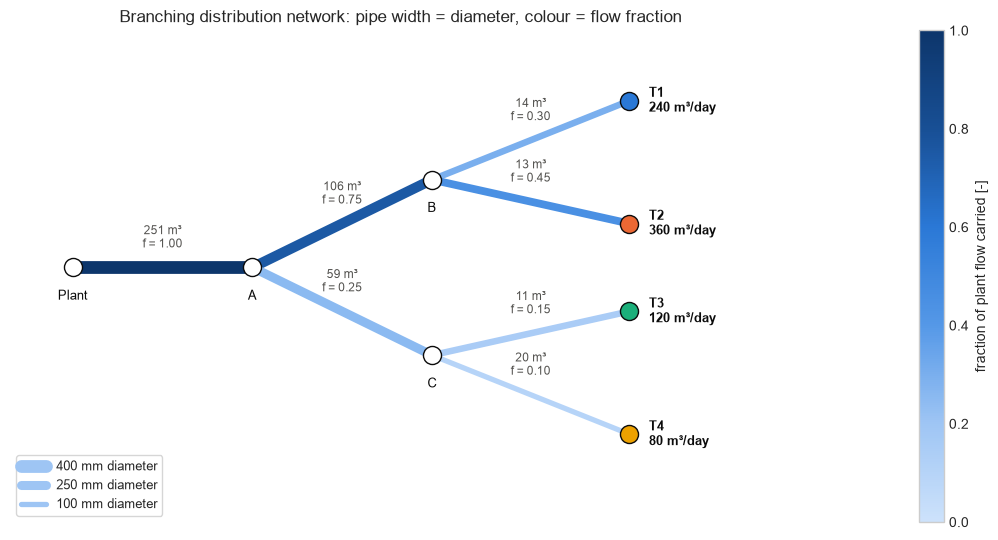

In [3]:
node_xy = {
    "Plant": (0.0, 0.0),
    "A": (2.0, 0.0),
    "B": (4.0, 1.0),
    "C": (4.0, -1.0),
    "T1": (6.2, 1.9),
    "T2": (6.2, 0.5),
    "T3": (6.2, -0.5),
    "T4": (6.2, -1.9),
}

fig, ax = plt.subplots(figsize=(11, 5.5))
norm = Normalize(vmin=0.0, vmax=1.0)

for _name, seg in segments.iterrows():
    x0, y0 = node_xy[seg["from"]]
    x1, y1 = node_xy[seg["to"]]
    ax.plot(
        [x0, x1],
        [y0, y1],
        color=BLUE_RAMP(norm(seg["flow_fraction"])),
        linewidth=2 + 18 * seg["diameter"],
        solid_capstyle="round",
        zorder=1,
    )
    ax.annotate(
        f"{seg['volume']:.0f} m³\nf = {seg['flow_fraction']:.2f}",
        xy=((x0 + x1) / 2, (y0 + y1) / 2),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=INK_SOFT,
    )

for node, (x, y) in node_xy.items():
    is_tap = node in TAP_COLORS
    ax.plot(x, y, "o", markersize=13, color=TAP_COLORS.get(node, "#ffffff"), markeredgecolor=INK, zorder=3)
    label = f"{node}\n{demand[node]:.0f} m³/day" if is_tap else node
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(14, 0) if is_tap else (0, -16),
        textcoords="offset points",
        ha="left" if is_tap else "center",
        va="center" if is_tap else "top",
        fontsize=9.5,
        color=INK,
        fontweight="bold" if is_tap else "normal",
    )

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=BLUE_RAMP), ax=ax, label="fraction of plant flow carried [-]", pad=0.12
)
ax.legend(
    handles=[
        Line2D([], [], color="#9ec5f4", lw=2 + 18 * d, solid_capstyle="round", label=f"{d * 1000:.0f} mm diameter")
        for d in (0.40, 0.25, 0.10)
    ],
    loc="lower left",
    frameon=True,
    fontsize=9,
)
ax.set_title("Branching distribution network: pipe width = diameter, colour = flow fraction", fontsize=12)
ax.set_xlim(-0.7, 8.0)
ax.set_ylim(-2.9, 2.7)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2. Effective Pore Volumes

Each path's effective pore volume is the sum of $V_i / f_i$ over its segments. Comparing it with the
physical water volume held in the same pipes shows how strongly the thin, low-flow branches are
inflated.

In [4]:
v_effective = pd.Series({
    tap: (segments.loc[path, "volume"] / segments.loc[path, "flow_fraction"]).sum() for tap, path in paths.items()
})
v_physical = pd.Series({tap: segments.loc[path, "volume"].sum() for tap, path in paths.items()})

overview = pd.DataFrame({
    "demand [m³/day]": demand,
    "demand fraction [-]": demand_fraction,
    "physical path volume [m³]": v_physical,
    "effective pore volume [m³]": v_effective,
    "mean travel time [h]": v_effective / plant_flow_mean * 24,
})
print(overview.round(2))

    demand [m³/day]  demand fraction [-]  physical path volume [m³]  \
T1            240.0                 0.30                     371.49   
T2            360.0                 0.45                     369.92   
T3            120.0                 0.15                     320.84   
T4             80.0                 0.10                     329.87   

    effective pore volume [m³]  mean travel time [h]  
T1                      439.82                 13.19  
T2                      420.62                 12.62  
T3                      557.63                 16.73  
T4                      683.30                 20.50  


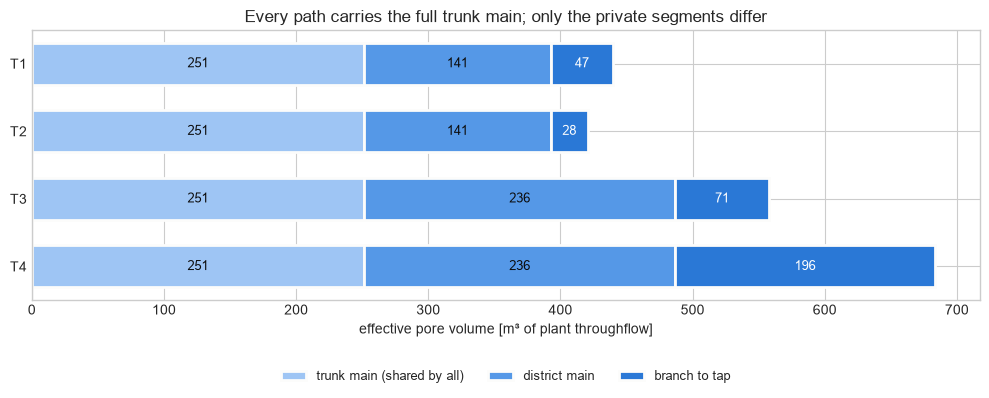

In [5]:
depth_labels = ["trunk main (shared by all)", "district main", "branch to tap"]
fig, ax = plt.subplots(figsize=(10, 4.2))

taps = list(paths)
left = np.zeros(len(taps))
for depth, label in enumerate(depth_labels):
    widths = np.array([
        segments.loc[paths[tap][depth], "volume"] / segments.loc[paths[tap][depth], "flow_fraction"] for tap in taps
    ])
    ax.barh(taps, widths, left=left, height=0.62, color=BLUES[depth + 1], edgecolor="#fcfcfb", linewidth=2, label=label)
    for tap_index, (start, width) in enumerate(zip(left, widths, strict=True)):
        ax.annotate(
            f"{width:.0f}",
            xy=(start + width / 2, tap_index),
            ha="center",
            va="center",
            fontsize=9,
            color="#ffffff" if depth >= 2 else INK,
        )
    left += widths

ax.set_xlabel("effective pore volume [m³ of plant throughflow]")
ax.set_title("Every path carries the full trunk main; only the private segments differ", fontsize=12)
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

The trunk contributes an identical 251 m³ to all four paths — visible as the shared leftmost block.
T4 holds the *least* water of any path yet has the *largest* effective pore volume, because its
2.5 km branch carries only 10 % of the plant flow.

## 3. Transport of a Contamination Pulse

A three-hour contamination event at the plant travels through the network under a strongly varying
diurnal production pattern. The pulse is tracked to every monitoring point at once by handing the
four effective pore volumes to the advection model.

In [6]:
tedges = pd.date_range("2025-06-01", "2025-06-08", freq="h")
tmid = tedges[:-1] + (tedges[1:] - tedges[:-1]) / 2

# Diurnal production: minimum before dawn, maximum in the afternoon
hours = np.asarray(tmid.hour, dtype=float) + np.asarray(tmid.minute, dtype=float) / 60.0
flow = plant_flow_mean * (1.0 - 0.75 * np.cos(2 * np.pi * (hours - 14.0) / 24.0))

# Contamination pulse leaving the plant on 2 June, 06:00-09:00
cin = np.zeros(len(tmid))
cin[(tmid >= pd.Timestamp("2025-06-02 06:00")) & (tmid < pd.Timestamp("2025-06-02 09:00"))] = 1.0

cout = {
    tap: infiltration_to_extraction(
        cin=cin,
        flow=flow,
        tedges=tedges,
        cout_tedges=tedges,
        aquifer_pore_volumes=np.array([v_effective[tap]]),
    )
    for tap in paths
}

for tap, concentration in cout.items():
    print(f"{tap}: peak {np.nanmax(concentration):.3f} at {tmid[np.nanargmax(concentration)]}")

T1: peak 1.000 at 2025-06-03 00:30:00
T2: peak 1.000 at 2025-06-03 00:30:00
T3: peak 1.000 at 2025-06-03 02:30:00
T4: peak 1.000 at 2025-06-03 04:30:00


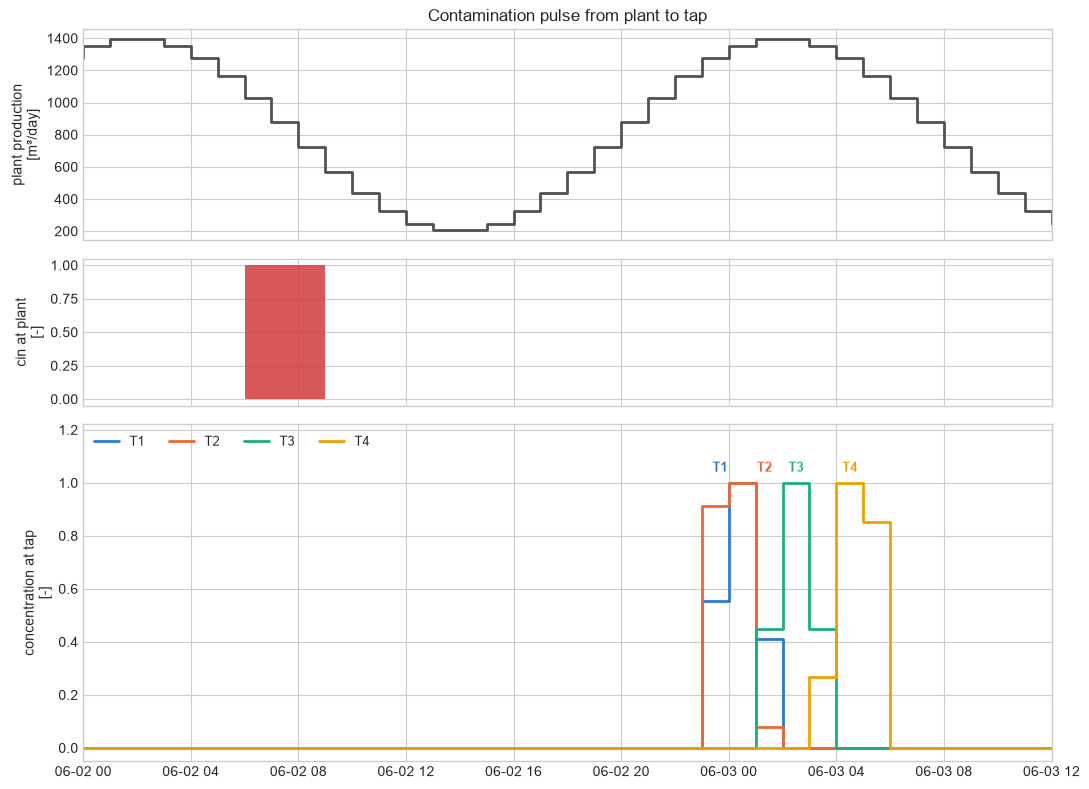

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, height_ratios=[1, 0.7, 1.6])

axes[0].plot(*step_plot_coords(tedges, flow), color=INK_SOFT, linewidth=2)
axes[0].set_ylabel("plant production\n[m³/day]")
axes[0].set_title("Contamination pulse from plant to tap", fontsize=12)

axes[1].fill_between(*step_plot_coords(tedges, cin), color="#d03b3b", alpha=0.85, linewidth=0)
axes[1].set_ylabel("cin at plant\n[-]")

# T1 and T2 arrive together, so their direct labels are nudged apart horizontally
label_offsets = {"T1": (-16, 8), "T2": (16, 8), "T3": (0, 8), "T4": (0, 8)}
for tap, concentration in cout.items():
    axes[2].plot(*step_plot_coords(tedges, concentration), color=TAP_COLORS[tap], linewidth=2, label=tap)
    peak = int(np.nanargmax(concentration))
    axes[2].annotate(
        tap,
        xy=(tmid[peak], concentration[peak]),
        xytext=label_offsets[tap],
        textcoords="offset points",
        ha="center",
        fontsize=9.5,
        fontweight="bold",
        color=TAP_COLORS[tap],
    )
axes[2].set_ylabel("concentration at tap\n[-]")
axes[2].set_ylim(-0.05, 1.22)
axes[2].set_xlim(date2num(pd.Timestamp("2025-06-02")), date2num(pd.Timestamp("2025-06-03 12:00")))
axes[2].legend(loc="upper left", ncol=4, fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

All four monitoring points see the pulse at nearly full strength but at different times, and the
arriving pulse is *stretched* relative to the three-hour release: production drops overnight, so the
same volume of water takes longer to pass. The plug flow assumption keeps the pulse sharp — real
networks smear it, which is discussed at the end.

## 4. Disinfectant Residual

Chlorine decays first order in contact time, so the residual at a tap follows directly from its
residence time, $c/c_0 = \exp(-k\,\tau)$. Residence times move with the diurnal production pattern,
which makes the residual at the far end of the network fluctuate over the day.

In [8]:
decay_rate = 0.5  # first-order chlorine decay [1/day]

residence_times = rt.full(
    flow=flow,
    tedges=tedges,
    cout_tedges=tedges,
    aquifer_pore_volumes=v_effective.to_numpy(),
    direction="extraction_to_infiltration",
)
residual = np.exp(-decay_rate * residence_times)

summary = pd.DataFrame(
    {
        "min travel time [h]": residence_times.min(axis=1) * 24,
        "max travel time [h]": residence_times.max(axis=1) * 24,
        "min residual [-]": residual.min(axis=1),
        "max residual [-]": residual.max(axis=1),
    },
    index=list(v_effective.index),
)
print(summary.round(3))

    min travel time [h]  max travel time [h]  min residual [-]  \
T1                7.734               17.480             0.695   
T2                7.394               17.095             0.700   
T3                9.822               19.734             0.663   
T4               12.049               21.977             0.633   

    max residual [-]  
T1             0.851  
T2             0.857  
T3             0.815  
T4             0.778  


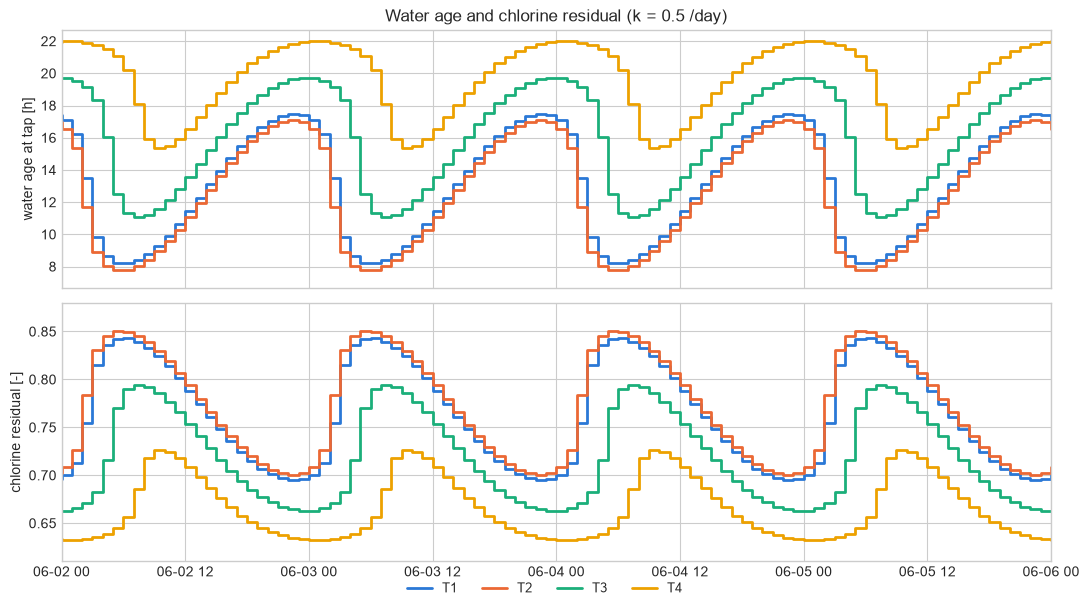

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for row, tap in enumerate(v_effective.index):
    axes[0].plot(*step_plot_coords(tedges, residence_times[row] * 24), color=TAP_COLORS[tap], linewidth=2, label=tap)
    axes[1].plot(*step_plot_coords(tedges, residual[row]), color=TAP_COLORS[tap], linewidth=2)

axes[0].set_ylabel("water age at tap [h]")
axes[0].set_title(f"Water age and chlorine residual (k = {decay_rate} /day)", fontsize=12)
axes[1].set_ylabel("chlorine residual [-]")
axes[1].set_xlim(date2num(pd.Timestamp("2025-06-02")), date2num(pd.Timestamp("2025-06-06")))
axes[1].margins(y=0.1)
fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Scope and Limitations

The mapping is exact for a single-source tree network under proportional demand. Four situations
fall outside it:

- **Merging flows.** A split leaves concentration unchanged, but a loop or a second treatment plant
  mixes two different transport histories at a node. The single-`cin` streamtube model has no way to
  express that blend. Looped grids are approximated at best, and only where one direction dominates.
- **Non-proportional demand.** An industrial consumer peaking at night while households peak in the
  morning makes the flow fractions $f_i$ time dependent, so the effective volumes are no longer
  constants. Separate calibrations per demand regime are a workaround.
- **Flow reversals.** The model requires strictly forward transport along a fixed path.
- **Dispersion in dead ends.** Turbulent mains approach plug flow, but small-diameter, low-flow
  service lines are laminar and smear a pulse considerably. Replacing a path's single sharp volume
  with a narrow gamma distribution around it — `gamma_infiltration_to_extraction` — restores the
  smearing, exactly as macrodispersion is handled in the aquifer case.

A storage tank is a special case worth noting: a well-mixed tank has an exponential residence time
distribution, which is a gamma distribution with $\alpha = 1$ and $\beta = V_{\mathrm{tank}} / f$.
Pipes in series with it contribute plug volume, which enters as the `loc` parameter. The equivalence
holds exactly in the cumulative-flow domain, so it survives varying production.

## Summary

- A branching network maps onto a discrete `aquifer_pore_volumes` distribution by giving each
  plant-to-tap path an effective volume $\sum_i V_i / f_i$.
- Segments are divided by *their own* flow fraction, so a shared trunk enters every downstream path
  in full — plug behaviour up to the junction is preserved automatically.
- Travel time and disinfectant residual at each tap follow from that single number per path.